<table align="left" style="border-style: hidden" class="table"> <tr><td class="col-md-2"><img style="float: left; width: 200px; height: 200px;" src="../logo.png" alt="Data 140 Logo" style="width: 120px;"/></td><td><div align="left"><h3 style="margin-top: 0;">Probability for Data Science</h3><h4 style="margin-top: 20px;">UC Berkeley, Spring 2026</h4><p>Ani Adhikari</p>CC BY-NC-SA 4.0</div></td></tr></table><!-- not in pdf -->

This content is protected and may not be shared, uploaded, or distributed.

In [2]:
from prob140 import *
from datascience import *
import numpy as np
from scipy import special
from scipy import stats

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.style.use('fivethirtyeight')

# Homework 2 (Due Monday, February 2nd at 5 PM) #

### Instructions

Your homeworks will generally have two components: a written portion and a portion that also involves code.  Written work should be completed on paper, and coding questions should be done in the notebook. Start the work for the written portions of each section on a new page. You are welcome to $\LaTeX$ your answers to the written portions, but staff will not be able to assist you with $\LaTeX$ related issues. 

It is your responsibility to ensure that both components of the lab are submitted completely and properly to Gradescope. **Make sure to assign each page of your pdf to the correct question. Refer to the bottom of the notebook for submission instructions.**

Every answer should contain a calculation or reasoning. For example, a calculation such as $(1/3)(0.8) + (2/3)(0.7)$ or `sum([(1/3)*0.8, (2/3)*0.7])`is fine without further explanation or simplification. If we want you to simplify, we'll ask you to. But just ${5 \choose 2}$ by itself is not fine; write "we want any 2 out of the 5 frogs and they can appear in any order" or whatever reasoning you used. Reasoning can be brief and abbreviated, e.g. "product rule" or "not mutually exclusive."

\newpage

## 1. Random Coin ##

This exercise is an introduction to experiments in which randomizing a parameter can affect dependence and independence. The setting is simple but powerful: it demonstrates some fundamental ideas of Bayesian prediction. We will use the same ideas in more complex settings later in the course.

Suppose you have a coin that has a fixed (non-random) probability $p$ of heads. Under this assumption the tosses are independent, that is, knowing the results of some tosses doesn't change probabilities for how other tosses will come out. So for example the chance of two heads in two tosses is $p \cdot p$.

Now let's see what happens when the coin is picked randomly from a bunch of different coins. In this situation, even the chance of heads is random.

In a bag of coins, a proportion $f$ of the coins are fair; assume $0 < f < 1$. Of the remaining coins, half are biased towards tails and land heads with chance 0.1. The other half land heads with chance 0.9.

A coin is picked at random from the bag and tossed twice. Define the following events.

- $C_F$ is the event that the selected coin is fair, $C_T$ is the event that the selected coin is biased towards tails, and $C_H$ is the event that the selected coin is biased towards heads.
- $H_1$ is the event that the first toss lands heads and $H_2$ is the event that the second toss lands heads.

**a)** Find $P(C_H)$ in terms of $f$.

**b)** Draw (by hand) a tree diagram that shows all the outcomes of picking a coin and tossing it once. The first level of the tree should be a 3-way split into sub-branches corresponding to the 3 types of coins. Each of the 3 sub-branches should then be split 2 ways corresponding to the result of the toss. That should result in 6 branches. Write the appropriate probabilities on each sub-branch.

**c)** Use the tree in Part **b** to calculate $P(H_1)$. Simplify the answer and notice that it is very simple. Explain the simple answer intuitively by observing a symmetry in the set of coins.

**d)** Without calculation, fill in the blank with one of the symbols $>$, $<$, or $=$. Explain your reasoning. 

$P(C_H \mid H_1) ~ \underline{~~~~~~~~~~~~~~~} ~ P(C_H)$

**e)** Now use the tree in Part **b** to calculate $P(C_H \mid H_1)$ and show that it is consistent with your answers to Parts **a** and **d**.

**f)** Each of the 6 branches of the tree in Part **b** splits a further 2 ways corresponding to the result of the second toss. You don't have to turn in this larger tree but you should at least imagine it. Use this tree (carefully!) to fill in the blanks. Simplify your answers as much as possible. 

$P(H_2) ~ = ~ \underline{~~~~~~~~~~~~} $ and $P(H_1H_2) ~ = ~ \underline{~~~~~~~~~~~~}$.

**g)** One of the following statements is true. Pick the true statement and justify your choice both by calculation and by intuition.

1. $P(H_1H_2) = P(H_1)P(H_2)$
2. $P(H_2 \mid H_1) < P(H_2)$
3. $P(H_2 \mid H_1) > P(H_2)$

**h)** Are the events $H_1$ and $H_2$ independent? Answer the question by picking the correct one of the following options and filling in the blank with your reasoning.

1. Yes, because $\underline{~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~}$.
2. No, because $\underline{~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~}$.

a)
$$
P(C_H) = \frac{1-f}{2}
$$

c)
$$
P(H_1) 
= 0.5f + (\frac{1-f}{2}0.9) + (\frac{1-f}{2}0.1)
= 0.5
$$

不公平的硬币的概率为 0.9 0.1 且二者数量相等

d)
首先这两件事显然不是独立事件
因为第一次观察到出现正面后, 很可能抽取的是是公平或者偏向正面的硬币
在知道了硬币的投掷结果为 1 之后, 反向推出选取的是什么硬币的概率肯定不等于 $P(C_H)$
而且 $C_H$ 硬币偏向 H 的可能性更大 
因此 $P(C_H \mid H_1) > P(C_H)$

e)
$$
P(C_H \mid H_1) 
= \frac{P(C_H, H_1)}{P(H_1)}
= \frac{ \frac{1-f}{2} 0.9}{0.5}
= \frac{9}{5} (\frac{1-f}{2}) 
> P(C_H) = (\frac{1-f}{2})
$$

f)
因为两次抛掷是对称的, 因此第二次抛掷的概率应该同第一次的相同

$$
P(H_2) = 0.5
$$

$$
P(H_1H_2) 
= f(0.5)^2 + \frac{1-f}{2}(0.9)^2 + \frac{1-f}{2}(0.1)^2
= 0.41 - 0.16f
$$

g)
3

$$
P(H_2 \mid H_1)
= \frac{P(H_1 \cap H_2)}{P(H_1)}
= \frac{0.41 - 0.16f}{0.5}
$$

Since $f < 1$,

$$
\begin{aligned}
-0.16f &> -0.16,\\
0.41 - 0.16f &> 0.25,\\
\frac{0.41 - 0.16f}{0.5} &> 0.5.
\end{aligned}
$$

Therefore, if $P(H_2)=0.5$,

$$
P(H_2 \mid H_1) > P(H_2).
$$

因为第一次观察到出现正面后, 很可能抽取的是是公平或者偏向正面的硬币

h)
no

$$
P(H_1, H_2) \ne P(H_1)P(H_2)
$$

\newpage

## 2. Exact Value or Bound ##
In each part below, find the exact value of the probability if it is possible to do so with the information given. If it is not possible, provide the best lower and upper bounds you can. **Explain your choices.**

**a)** the chance that at least one of 10 flights at an airport is late, if each flight at the airport has a 1% chance of being late

**b)** the chance that there is at least one freshman and at least one sophomore in a simple random sample of 5 students taken from a group of 10 freshmen and 10 sophomores

**c)** the chance that it rains every day next week if the daily chances of rain are given by

$$
\begin{array}{|c|c|c|c|c|c|c|}
\hline
\text{Sun} & \text{Mon} & \text{Tue} & \text{Wed} & \text{Thu} & \text{Fri} & \text{Sat} \\
\hline
0.9 & 0.95 & 0.95 & 0.9 & 0.9 & 0.85 & 0.8 \\
\hline
\end{array}
$$

a)
无法判断航班晚点是否是独立事件

上界：

$$
P(\text{at least one late})
=
P(\text{flight 1 late}\cup \text{flight 2 late}\cup\cdots)
\le
\sum_{i=1}^{n}P(\text{flight }i\text{ late})
=
0.01n
$$

下界：

$$
P(\text{at least one late})
=
P(\text{flight 1 late}\cup \text{flight 2 late}\cup\cdots)
\ge
P(\text{flight }i\text{ late})
=
0.01
$$


b)
A = at least one freshman
B = at least one sophomore

$$
P(A, B)
= 1 - P(\text{not A or not B})
= 1 - \frac{\binom{10}{5} + \binom{10}{5}}{\binom{20}{5}}
$$

c)
这里我们不知道两天下雨是否是独立事件, 因此这里我们只能求出上下界

$$
P(\text{at least one day not rain})
=
P(\text{Mon not rain} \cup \text{Tues not rain} \cup \dots)
\le
\sum_{i=1}^{7} P(\text{day } i \text{ not rain})
$$

$$
P(\text{at least one day not rain})
=
P(\text{Mon not rain} \cup \text{Tues not rain} \cup \dots)
\ge
\max_{1\le i\le 7} P(\text{day } i \text{ not rain})
$$

$$
P(\text{all rain})
=
1-P(\text{at least one day not rain})
\ge
1-\sum_{i=1}^{7} P(\text{day } i \text{ not rain})
$$

$$
P(\text{all rain})
=
1-P(\text{at least one day not rain})
\le
1-\max_{1\le i\le 7} P(\text{day } i \text{ not rain})
$$


\newpage

## 3. Unions and Complements

Let $A_1, A_2, \ldots, A_n$ be events. You know that $\displaystyle \cup_{i=1}^n A_i$ is the event that at least one of $A_1, A_2, \ldots, A_n$ occurs, and that its probability can be found by the inclusion-exclusion formula if necessary. Appropriate use of the inclusion-exclusion formula can get us the probability of other related events as well. This exercise is a workout in these ideas.

**a)** A die is rolled 10 times. Let $N$ be the number of different faces that appear. Find $P(N < 6)$.

**b)** For $i = 1, 2, \ldots, n$, let $C_i = A_i^c$. That is, $C_i$ is the event that $A_i$ does not occur. In this part you will express three events as unions or complements of unions. That will allow you to find chances of such events by applying the inclusion-exclusion formula either directly or via complementation.

Here is a list of events, each of which is a union or a complement of a union.

- (A) $(\cup_{i=1}^n A_i)^c$
- (B) $\cup_{i=1}^n C_i$
- (C) $(\cup_{i=1}^n C_i)^c$

Match each event below with the correct choice from among (A), (B), and (C) above. Just enter the right choice in the blank. No reasoning is necessary.

- not all of $A_1, A_2, \ldots, A_n$ occur: $\underline{~~~~~~~~~~~~~~~~~~~}$
- none of $A_1, A_2, \ldots, A_n$ occurs: $\underline{~~~~~~~~~~~~~~~~~~~}$
- all of $A_1, A_2, \ldots, A_n$ occur: $\underline{~~~~~~~~~~~~~~~~~~~}$
 
**c)** Find the chance that all suits appear in a bridge hand of 13 cards dealt at random without replacement from a standard deck. [A standard deck consists of 13 cards in each of 4 suits, making 52 cards in all.]

a)
$$
P(N < 6) 
= \sum_{i=1}^{5} (-1)^{i+1} \binom{6}{i} (\frac{6-i}{6})^{10}
$$


b)

B
A
C


c) 

设 $A_i$ 表示第 i 个花色没有出现

$$
P
=
1 - P(A_1 \cup A_2 \cup A_3 \cup A_4)
= 
1 - \frac{ \binom{4}{1} \binom{39}{13} }{ \binom{52}{13} } + \frac{ \binom{4}{2} \binom{26}{13} }{ \binom{52}{13} } - \frac{ \binom{4}{3} \binom{13}{13} }{ \binom{52}{13} }
$$

\newpage

## 4. Counting Categories ##
In each part below, remember to **explain your answer. Don't just write down a formula.** You don't have to provide decimal answers. 

**Note:** See the video right at the bottom of [Section 5.4](https://data140.org/textbook/content/chapter-05/sampling-without-replacement/) (below the last Quick Check) for an effective approach.

A population consists of 6 individuals in each of 4 categories $A$, $B$, $C$, and $D$. A simple random sample of 12 individuals is chosen from the population.

**a)** Find the chance that the sample contains equal numbers of individuals in the four categories.

**b)** Find the chance that the sample contains 5 individuals in one category, 4 in another, 2 in a third, and 1 in the remaining category.

**c)** Say whether the statement below is true or false. If you say it's true, explain the reasoning. If you say it's false, provide the correct chance.

The chance that the sample contains 4 individuals in each of two categories, 3 individuals in another, and 1 in the remaining category is equal to $\displaystyle 4 \cdot 3 \cdot 2 \cdot 1 \cdot \frac{\binom{6}{4}\binom{6}{4}\binom{6}{3}\binom{6}{1}}{\binom{24}{12}}$.

**d)** Find the chance that the sample contains all 6 individuals in one category and equal numbers in the other three.



a)
因为有四个种类, 因此如果要数量相等, 那么每个种类只有三个
$$
P = \frac{(\binom{6}{3})^4}{\binom{24}{12}}
$$

b)
先分类再排序, 这里四个数量都不同, 因此有 $4!$ 中不同的排列方法
$$
P
= \frac{\binom{6}{5} \binom{6}{4} \binom{6}{2} \binom{6}{1}}{\binom{24}{12}} \times 4!
$$

c)
错误
其中一类的数量相等, 因此这里排列的时候应该只有 $3! \times 2$ 种方法
$$
P = \frac{ \binom{6}{4} \binom{6}{4} \binom{6}{3} \binom{6}{1} }{\binom{24}{12}} \times 3! \times 2
$$

d)
和上面一样, 先分类, 后排序 排列的方法只有 4 种
$ \frac{12-6}{3} = 2 $

$$
P = \frac{ \binom{6}{6} \binom{6}{2} \binom{6}{2} \binom{6}{2} }{\binom{24}{12}} \times 4
$$

\newpage

## 5. College Degrees

In the U.S., 38% of adults aged 25 and over have a four-year college degree.

In Parts **(b)-(d)** below, write a math expression for the chance. Please use the appropriate summation, not "...". Then use the appropriate code cell to find the numerical value of the chance, using `stats.binom.pmf`, `stats.binom.cdf`, and arithmetic. See [the textbook](https://data140.org/textbook/content/chapter-06/binomial-distribution/#binomial-probabilities-in-python) for a reference. The `stats` library of `scipy` has been imported in the top cell of this notebook.

**a)** As you know, and event is a subset of outcomes. For example, in 10 tosses of a fair coin, the event "more heads than tails" is the subset $\{ 6, 7, 8, 9, 10 \}$ of the outcome space of all possible numbers of heads.

In what follows, we will use the term *population* to mean US adults aged 25 and over, and a *success* to mean a draw that results in a person who has a four-year college degree.

Suppose I draw from the population at random with replacement. For each of the three events below, provide the corresponding subset of numbers of successes in the first 30 draws. You can use any reasonable notation such as $6, 7, \ldots, 15$, or $1-20$, or $0$, etc. Just be clear about which numbers of successes are in the event. No reasoning is needed.

- In my first 30 draws, the number of failures is twice the number of successes: $\underline{~~~~~~~~~~~~~~~~~~~}$
- At least 10 of my first 30 draws are successes: $\underline{~~~~~~~~~~~~~~~~~~~}$
- I have to draw more than 30 times to get 10 successes: $\underline{~~~~~~~~~~~~~~~~~~~}$
- I have to draw at most 30 times to get 10 successes: $\underline{~~~~~~~~~~~~~~~~~~~}$

**b)** Use Part **a** to provide math expressions for the following two chances. Then use the appropriate code cell to find the numerical values of the chances.

- $P(\text{at least 10 successes in 30 draws}) = \underline{~~~~~~~~~~~~~~~~~~~~~~~~~~~~~}$
- $P(\text{at most 30 draws are needed to get 10 successes}) = \underline{~~~~~~~~~~~~~~~~~~~~~~~~~~~~~}$

a)

10

10 - 30

0, 1, 2, 3, 4, 5, 6, 7, 8, 9

10 - 30

In [3]:
# Answer to b
p = 0.38

# P(at least 10 successes in 30 draws)
p1 = 1 - stats.binom.cdf(9, 30, p)

# P(at most 30 draws are needed to get 10 successes)
p2 = 1 - stats.binom.cdf(9, 30, p)

p1, p2

(0.75990997691204432, 0.75990997691204432)


**c)** Apply the thought process you used in Parts **a** and **b** to write a math expression for $P(\text{at least 30 draws are needed to get 10 successes})$. You don't have to compute it numerically.

**d)** Suppose my friend and I both draw from the population at random with replacement, independently of each other. Suppose I make 30 draws and my friend makes 20 draws. What is the chance that I get more successful draws than my friend? Write a math expression for the chance. Then use the appropriate code cell to find its numerical value.

c)
$$
P
= \sum_{i=0}^{9} { \binom{29}{i} p^i(1-p)^{29-i} }
$$

d)


In [4]:
# Answer to d (you can use more than one line of code)

x = stats.binom.pmf(np.arange(1, 31), 30, p)
y = stats.binom.cdf(np.arange(0, 20), 20, p)
x, y

(array([  1.08708586e-05,   9.66103724e-05,   5.52652883e-04,
          2.28637846e-03,   7.28690941e-03,   1.86090429e-02,
          3.91047168e-02,   6.89062953e-02,   1.03235955e-01,
          1.32874665e-01,   1.48071474e-01,   1.43693016e-01,
          1.21942957e-01,   9.07547811e-02,   5.93321580e-02,
          3.40920666e-02,   1.72077604e-02,   7.61705521e-03,
          2.94853750e-03,   9.93942481e-04,   2.90090739e-04,
          7.27353613e-05,   1.55059957e-05,   2.77190514e-06,
          4.07738305e-07,   4.80584851e-08,   4.36373341e-09,
          2.86558530e-10,   1.21125964e-11,   2.47461647e-13]),
 array([  7.04423426e-05,   9.33929122e-04,   5.96165053e-03,
          2.44506906e-02,   7.26116577e-02,   1.67069297e-01,
          3.11802775e-01,   4.89218008e-01,   6.65917856e-01,
          8.10317732e-01,   9.07671196e-01,   9.61915062e-01,
          9.86849743e-01,   9.96254386e-01,   9.99136455e-01,
          9.99843026e-01,   9.99978357e-01,   9.99997874e-01,
      

In [5]:
prob = np.sum(x[:20] * y) + np.sum(x[20:])
prob

0.83190894629882217

\newpage

## 6. Poisson Approximation at Both Ends ##
Consider $n$ independent Bernoulli $(p)$ trials.

**a)** Fill in the blanks with names of distributions along with parameters in parentheses: If $n = 1000$ and $p=0.003$, the distribution of the number of successes is exactly $\underline{~~~~~~~~~~~~~~~~~~~~~~~~~~~}$ $(\underline{~~~~~~~~~~~~ })$ and approximately $\underline{~~~~~~~~~~~~~~~~~~~~~~ }$ $(\underline{~~~~~~~~~~~~ })$.

**b)** Pick the right choice to complete the sentence, and justify your choice.

For $k \le n$, the chance of $k$ successes in $n$ independent Bernoulli $(p)$ trials is equal to

1. 1 minus the chance of $k$ successes in $n$ independent Bernoulli $(1-p)$ trials
2. The chance of $n-k$ successes in $n$ independent Bernoulli $(1-p)$ trials
3. 1 minus the chance of $n-k$ successes in $n$ independent Bernoulli $(1-p)$ trials

**c)** Let $n$ be large and let $p$ be close to 1. Find a Poisson approximation to $p_k$ (the chance of $k$ successes) by an appropriate use of the Poisson approximation to the binomial derived in the textbook. 

**Note:** Don't try to derive a new limit from scratch. Just use the limit already derived in the textbook, but appropriately.

**d)** Plot the probability histogram of the binomial (1000, 0.997) distribution, and overlay your Poisson approximation from Part **c**. For computing Poisson probabilities, see the [textbook](https://data140.org/textbook/content/chapter-06/law-of-small-numbers/#poisson-probabilities-in-python). Please don't plot the entire range of the binomial. Choose an informative range of values on the horizontal axis.

a)
$$
\sum_{k=0}^{1000} { \binom{n}{k} p^k (1-p)^{1000-k} }
$$

$$
np = 3
$$

b)
2

(1-p) 是失败的概率
(n-k) 是失败的次数
二者结合相当于题目的另一种表述

c)
令 $ q = 1-p $, 那么 $q \to 0$. 令 $\mu = nq$

那么就只需要近似出失败次数的泊松近似
$$
Q(k) 
\sim 
e^{-\mu}\frac{\mu^k}{k!}
$$

要求 k 次成功, 那么就是要求 n-k 次失败, 有
$$
P(k) 
= 
Q(n-k) 
\sim
e^{-\mu} \frac{\mu^{n-k}}{(n-k)!}
$$
其中 $\mu = n(1-p)$

d)
this i

(990.0, 1001.0)

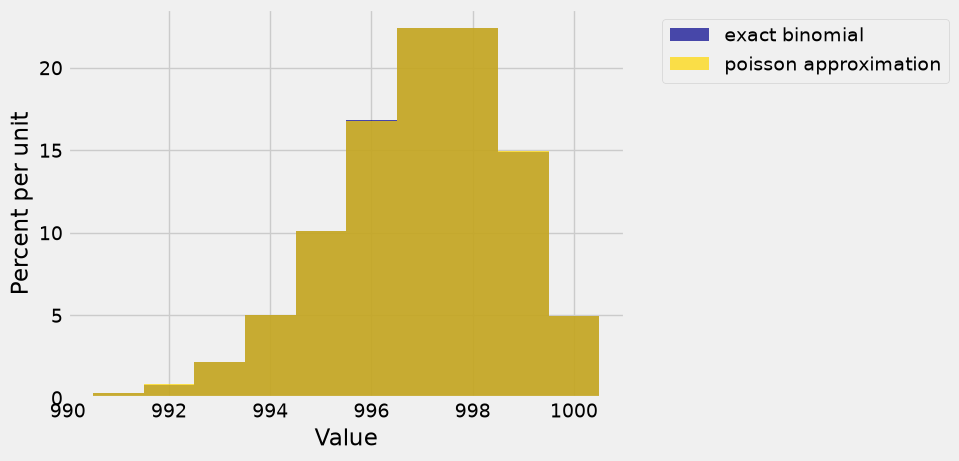

In [6]:
# Answer to d
from math import e
n = 1000
p = 0.997

k = np.arange(n+1)            # array of possible values
binomial_probs = stats.binom.pmf(k, n, p)   # array of exact binomial probabilities

def poisson_approximation_pmf(j):
    """Returns the Poisson approximation to the
    exact binomial probability of j successes"""
    mu = n * (1-p)
    return stats.poisson.pmf(n-j, mu)

exact_binomial = Table().values(k).probabilities(binomial_probs)
poisson_approximation = Table().values(k).probability_function(poisson_approximation_pmf)

Plots('exact binomial', exact_binomial, 'poisson approximation', poisson_approximation)
plt.xlim(990, 1001)

## Submission Instructions ##

Many assignments throughout the course will have a written portion and a code portion. Please follow the directions below to properly submit both portions.

### Written Portion ###
*  Scan all the pages into a PDF. You can use any scanner or a phone using applications such as CamScanner. Please **DO NOT** simply take pictures using your phone. 
* Please start a new page for each question. If you have already written multiple questions on the same page, you can crop the image in CamScanner or fold your page over (the old-fashioned way). This helps expedite grading.
* It is your responsibility to check that all the work on all the scanned pages is legible.
* If you used $\LaTeX$ to do the written portions, you do not need to do any scanning; you can just download the whole notebook as a PDF via LaTeX.

### Code Portion ###
* Save your notebook using `File > Save Notebook`.
* Generate a PDF file using `File > Save and Export Notebook As > PDF`. This might take a few seconds and will automatically download a PDF version of this notebook.
    * If you have issues, please post a follow-up on the general Homework 2 Ed thread.
    
### Submitting ###
* Combine the PDFs from the written and code portions into one PDF. [Here](https://smallpdf.com/merge-pdf) is a useful tool for doing so. 
* Submit the assignment to Homework 2 on Gradescope. 
* **Make sure to assign each page of your pdf to the correct question.**
* **It is your responsibility to verify that all of your work shows up in your final PDF submission.**

If you are having difficulties scanning, uploading, or submitting your work, please read the [Ed Thread](https://edstem.org/us/courses/94054/discussion/7533569) on this topic and post a follow-up on the general Homework 2 Ed thread.

## **We will not grade assignments which do not have pages selected for each question.** ##